Давайте подивимося, як LSTM можна використовувати для побудови нейронної мережі прогнозування часових.

Будемо працювати з задачею прогнозування кількості пасажирів міжнародних авіаліній. З цим набором даних ми вже працювали в лекції "Time Series Analysis" і ви зможете порівняти результати :)

Задача полягає в тому, щоб за заданими роком і місяцем передбачити кількість пасажирів міжнародних авіаліній в одиницях виміру 1,000. Дані охоплюють період з січня 1949 року по грудень 1960 року, тобто 12 років, зі 144 спостереженнями.

Це регресійна задача. Тобто, знаючи кількість пасажирів (в тисячах) за останні місяці, можна передбачити, якою буде кількість пасажирів у наступному місяці. Набір даних має лише одну характеристику: "Кількість пасажирів" - `Passengers`.

Далі вже наведений код для читання даних, але нам їх ще треба буде трошки обробити.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

In [2]:
# Завантаження даних
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.set_index('Month', inplace=True)
display(df.head())

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


**Завдання 1.** Створіть змінну типу `numpy.ndarray`, яка містить значення кількості пасажирів в форматі `float32`. Такий формат даних нам треба для тренування нейромережі.

In [3]:
timeseries = df['Passengers'].values.astype('float32')
timeseries[:5]

array([112., 118., 132., 129., 121.], dtype=float32)

Очікуваний результат:
```array([112., 118., 132., 129., 121.], dtype=float32)```

**Завдання 2**. Розбийте дані на тренувальні і валідаційні у співвідношенні 67% йде у тренування, 33 - у валідацію. Памʼятаємо, що ми працюємо з tim series, відповідно, навчаємось на давніших, валідуємось - на новіших.

In [4]:
train_size = int(len(timeseries) * 0.67)
test_size = len(timeseries) - train_size

In [5]:
train = timeseries[:train_size]
test = timeseries[train_size:]

print(f'train: {len(train)}, test: {len(test)}')

train: 96, test: 48


**Завдання 3**.

Реалізуйте функцію `create_dataset`, яка перетворить одномірний часовий ряд (набір даних) у формат, придатний для тренування нейромережі.

Функція повинна приймати два аргументи:
- `dataset` — numpy-масив часового ряду,
- `lookback` — кількість попередніх кроків, які використовуватимуться для передбачення.

Функція повинна повернути два **тензори** PyTorch:
- `X` — набір ознак (вікно попередніх значень),
- `y` — цільові значення (наступні після вікна кроки).

Дані ми будемо подавати моделі в наступному форматі:
`
tensor([[112.],
        [118.],
        [132.],
        [129.],
        [121.]])
`
Відповідно першою розмірністю буде йти розмір вхідного батча, а другою - розмір вхіднизх даних і в нас це 1, бо лише одне значення на вході щоразу.

Після виконання завдання запустіть код нижче. Ми будемо передбачати на основі кількості пасажирів в попередній день кількість пасажирів в наступний, тому `lookback == 1`.

In [6]:
def create_dataset(dataset, lookback):
    X, y = [], []
    for i in range(len(dataset) - lookback):
        X.append(dataset[i:i + lookback])
        y.append(dataset[i + lookback])

    X = torch.tensor(np.array(X), dtype=torch.float32)
    y = torch.tensor(np.array(y), dtype=torch.float32).reshape(-1, 1)
    return X, y

In [7]:
lookback = 1
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])


Очікуваний результат:
```
torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])
```

**Завдання 4**.

Зверніть увагу на розмірності в попередньому завданні. Ми
З допомогою модуля `torch.nn` опишіть клас `AirModel`, який є нейронною мережею для прогнозування кількості пасажирів за допомогою LSTM.

1. **Конструктор класу** повинен приймати параметри `hidden_size`, `num_layers` та ініціювати шари:
   - LSTM-шар з наступними параметрами:
     - `input_size` — кожна точка часового ряду є окремим входом,,
     - `hidden_size` — заданий в конструкторі класу мережі,
     - `num_layers=1` — кількість шарів LSTM, задана в конструкторі мережі,
     - `batch_first=True` — визначає, що першим виміром є розмір батчу.
   - Лінійний шар (`nn.Linear`) для перетворення виходу LSTM на прогноз однієї точки.

2. **Метод forward** повинен виконувати наступні дії:
   - Передати вхідний тензор через LSTM-шар і отримати виходи (ігноруючи приховані стани).
   - Пропустити вихід LSTM через лінійний шар для отримання остаточного прогнозу.

Створіть об'єкт класу `AirModel` зі значеннями параметрів `hidden_size=50`, `num_layers=1` і протестуйте роботу моделі на вхідному тензорі `tensor([[112.]])`. На цьому етапі ми маємо переконатись, що модель здатна генерувати передбачення з рандомно ініційованими вагами.

In [8]:
class AirModel(nn.Module):
    def __init__(self, hidden_size, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(-1)
        out, _ = self.lstm(x)
        out = self.linear(out[:, -1, :])
        return out

In [9]:
model = AirModel(hidden_size=50, num_layers=1)
print(model)

AirModel(
  (lstm): LSTM(1, 50, batch_first=True)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)


In [10]:
sample_input = torch.tensor([[112.]], dtype=torch.float32)
print(f'Передбачення для входу {sample_input.tolist()}: {model(sample_input).tolist()}')

Передбачення для входу [[112.0]]: [[-0.4230184853076935]]


**Завдання 5**.

Створіть об'єкт DataLoader для завантаження даних, використовуючи тренувальні вибірки `X_train` та `y_train`. Ваш DataLoader повинен виконувати наступні вимоги:

1. Використовувати клас `TensorDataset`, щоб об'єднати тензори ознак `X_train` і цільових значень `y_train`.
2. Дані повинні завантажуватися невеликими батчами розміром 8 за допомогою параметра `batch_size`.
3. Використовувати параметр `shuffle=True`, щоб дані перемішувалися перед кожною епохою тренування.


In [11]:
train_ds = TensorDataset(X_train, y_train)
train_dl = DataLoader(train_ds, batch_size=8, shuffle=True)

In [12]:
print(f'Кількість батчів: {len(train_dl)}\n')

X_batch, y_batch = next(iter(train_dl))
print(X_batch.shape)
print(y_batch.shape)

print('\nПерший батч (X, y):')
X_batch, y_batch

Кількість батчів: 12

torch.Size([8, 1])
torch.Size([8, 1])

Перший батч (X, y):


(tensor([[180.],
         [235.],
         [269.],
         [277.],
         [170.],
         [237.],
         [193.],
         [270.]]),
 tensor([[201.],
         [229.],
         [270.],
         [317.],
         [158.],
         [211.],
         [181.],
         [315.]]))

**Завдання 6**.

1. Реалізуйте навчання нейронної мережі `AirModel` для прогнозування часових рядів, використовуючи Adam-оптимізатор та функцію втрат MSE (середньоквадратичну похибку).
2. Створіть цикл тренування для 2000 епох, у якому на кожній епосі:
   - Виконуйте крок тренування моделі (прямий прохід, обчислення похибки, зворотний прохід і оновлення ваг).
   - Підраховуйте середню похибку на кожному батчі даних і зберігайте її у списку `losses`.
3. Раз на 100 епох проводьте валідацію моделі:
   - Перевіряйте модель на тренувальних та тестових даних без оновлення ваг.
   - Обчислюйте корінь середньоквадратичної похибки (RMSE) для тренувальної та тестової вибірок і виводьте результати на екран.
   
**Примітка:**
- Використовуйте вже створений `DataLoader` для отримання батчів даних.
- Валідацію виконуйте в режимі `eval()`, вимикаючи обчислення градієнтів з `torch.no_grad()`.

**Приклад виходу:**
```
Epoch 0: train RMSE 12.3456, test RMSE 15.6789
Epoch 100: train RMSE 9.8765, test RMSE 12.3456
...
```

In [13]:
def train_air_model(model, train_loader, X_train, y_train, X_test, y_test, n_epochs=2000, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    metrics = []

    for epoch in range(n_epochs):
        model.train()
        batch_losses = []

        for X_batch, y_batch in train_loader:
            # forward
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            # backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        losses.append(float(np.mean(batch_losses)))

        # валідація кожні 100 епох
        if epoch % 100 == 0 or epoch == n_epochs - 1:
            model.eval()
            with torch.no_grad():
                train_rmse = torch.sqrt(criterion(model(X_train), y_train)).item()
                test_rmse = torch.sqrt(criterion(model(X_test), y_test)).item()
            metrics.append((epoch, train_rmse, test_rmse))
            print(f'Epoch {epoch}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}')

    return losses, metrics

In [14]:
model = AirModel(hidden_size=50, num_layers=1)
losses, metrics_50 = train_air_model(model, train_dl, X_train, y_train, X_test, y_test, n_epochs=2000, lr=0.001)

Epoch 0: train RMSE 225.5967, test RMSE 422.0104
Epoch 100: train RMSE 188.0504, test RMSE 382.7210
Epoch 200: train RMSE 154.9720, test RMSE 347.1492
Epoch 300: train RMSE 126.9164, test RMSE 315.4711
Epoch 400: train RMSE 103.5561, test RMSE 286.6169
Epoch 500: train RMSE 85.3192, test RMSE 260.7626
Epoch 600: train RMSE 68.8793, test RMSE 235.8887
Epoch 700: train RMSE 55.7656, test RMSE 212.8140
Epoch 800: train RMSE 45.9931, test RMSE 192.2327
Epoch 900: train RMSE 38.4728, test RMSE 173.8051
Epoch 1000: train RMSE 33.4137, test RMSE 157.9248
Epoch 1100: train RMSE 29.6608, test RMSE 144.1763
Epoch 1200: train RMSE 28.2714, test RMSE 133.1767
Epoch 1300: train RMSE 27.9836, test RMSE 125.7124
Epoch 1400: train RMSE 25.4128, test RMSE 118.5595
Epoch 1500: train RMSE 24.4024, test RMSE 113.1208
Epoch 1600: train RMSE 23.9837, test RMSE 108.8133
Epoch 1700: train RMSE 23.9546, test RMSE 104.9509
Epoch 1800: train RMSE 23.5375, test RMSE 102.5335
Epoch 1900: train RMSE 24.0555, test R

Спробуємо нормалізувати дані для покращення результату:

In [15]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train.reshape(-1, 1)).flatten()
test_scaled = scaler.transform(test.reshape(-1, 1)).flatten()

print(train_scaled[:5])

[0.02588999 0.04530746 0.09061491 0.08090615 0.05501619]


In [16]:
lookback = 1

X_train_scaled, y_train_scaled = create_dataset(train_scaled, lookback)
X_test_scaled, y_test_scaled = create_dataset(test_scaled, lookback)

print(X_train_scaled.shape)
print(y_train_scaled.shape)

torch.Size([95, 1])
torch.Size([95, 1])


In [17]:
train_ds_scaled = TensorDataset(X_train_scaled, y_train_scaled)
train_dl_scaled = DataLoader(train_ds_scaled, batch_size=8, shuffle=True)

In [18]:
model_scaled = AirModel(hidden_size=50, num_layers=1)

In [19]:
losses_scaled, metrics_scaled = train_air_model(model_scaled, train_dl_scaled, X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, n_epochs=2000, lr=0.001)         

Epoch 0: train RMSE 0.4983, test RMSE 1.1214
Epoch 100: train RMSE 0.0758, test RMSE 0.1567
Epoch 200: train RMSE 0.0744, test RMSE 0.1551
Epoch 300: train RMSE 0.0740, test RMSE 0.1568
Epoch 400: train RMSE 0.0739, test RMSE 0.1588
Epoch 500: train RMSE 0.0737, test RMSE 0.1623
Epoch 600: train RMSE 0.0737, test RMSE 0.1681
Epoch 700: train RMSE 0.0739, test RMSE 0.1650
Epoch 800: train RMSE 0.0739, test RMSE 0.1762
Epoch 900: train RMSE 0.0738, test RMSE 0.1669
Epoch 1000: train RMSE 0.0737, test RMSE 0.1738
Epoch 1100: train RMSE 0.0743, test RMSE 0.1645
Epoch 1200: train RMSE 0.0736, test RMSE 0.1730
Epoch 1300: train RMSE 0.0739, test RMSE 0.1699
Epoch 1400: train RMSE 0.0738, test RMSE 0.1685
Epoch 1500: train RMSE 0.0740, test RMSE 0.1806
Epoch 1600: train RMSE 0.0737, test RMSE 0.1698
Epoch 1700: train RMSE 0.0738, test RMSE 0.1702
Epoch 1800: train RMSE 0.0738, test RMSE 0.1787
Epoch 1900: train RMSE 0.0736, test RMSE 0.1753
Epoch 1999: train RMSE 0.0740, test RMSE 0.1688


In [20]:
def calculate_real_rmse(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    scaler
):
    model.eval()
    with torch.no_grad():
        train_pred_scaled = model(X_train).numpy()
        test_pred_scaled = model(X_test).numpy()

    train_pred_real = scaler.inverse_transform(train_pred_scaled)
    test_pred_real = scaler.inverse_transform(test_pred_scaled)
    y_train_real = scaler.inverse_transform(y_train.numpy())
    y_test_real = scaler.inverse_transform(y_test.numpy())

    train_rmse = np.sqrt(
        np.mean((train_pred_real - y_train_real) ** 2)
    )
    test_rmse = np.sqrt(
        np.mean((test_pred_real - y_test_real) ** 2)
    )

    return train_rmse, test_rmse

In [21]:
train_rmse_scaled_50, test_rmse_scaled_50 = calculate_real_rmse(
    model=model_scaled,
    X_train=X_train_scaled,
    y_train=y_train_scaled,
    X_test=X_test_scaled,
    y_test=y_test_scaled,
    scaler=scaler
)

print(f"Train RMSE у реальній шкалі: {train_rmse_scaled_50:.4f}")
print(f"Test RMSE у реальній шкалі: {test_rmse_scaled_50:.4f}")

Train RMSE у реальній шкалі: 22.8720
Test RMSE у реальній шкалі: 52.1740


Після нормалізації даних за допомогою MinMaxScaler модель почала навчатися стабільніше. У нормалізованій шкалі RMSE швидко зменшилась, а після повернення прогнозів до реальної шкали test RMSE значно кращий за результат без нормалізації. Отже, масштабування даних позитивно вплинуло на якість LSTM-моделі.

**Завдання 7.** Побудуйте графік лосів. Зробіть висновок з графіку, чи навчилась модель?

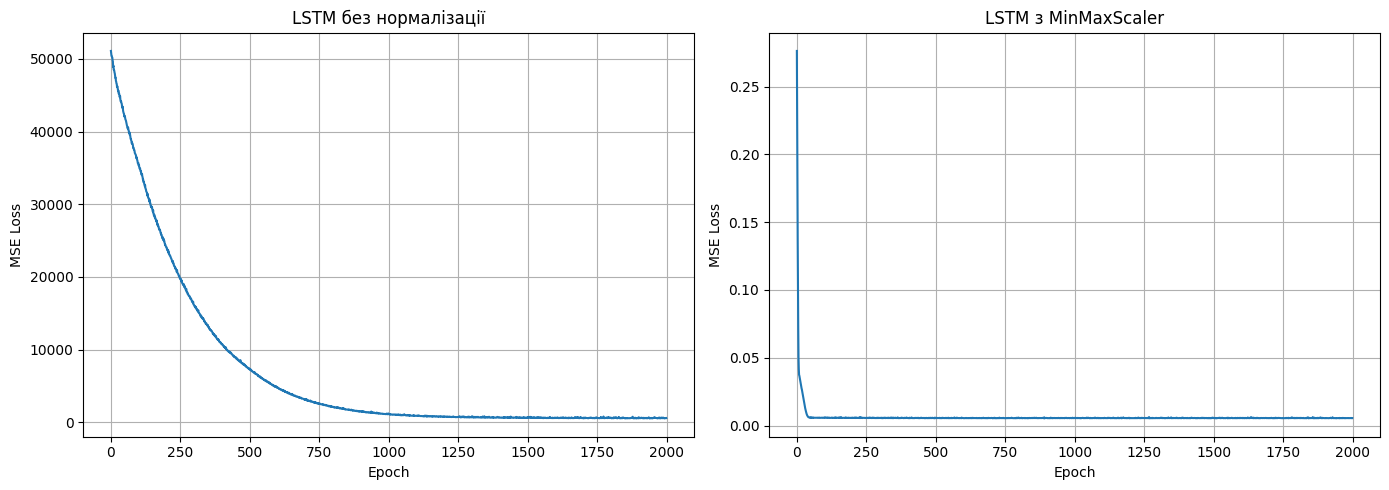

In [22]:
plt.figure(figsize=(14, 5))

# Без нормалізації
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title('LSTM без нормалізації')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)

# З нормалізацією
plt.subplot(1, 2, 2)
plt.plot(losses_scaled)
plt.title('LSTM з MinMaxScaler')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

Щоб краще зрозуміти якість прогнозу, ви можете побудувати графік з кодом нижче (а ще нижче - описано, що відбувається в цьому коді, бо це теж корисно зрозуміти):

In [23]:
def plot_predicts(
    model,
    X_train,
    X_test,
    title='LSTM',
    is_scaled=False,
    scaler=None
):
    if is_scaled and scaler is None:
        raise ValueError("Для is_scaled=True потрібно передати scaler")
    model.eval()

    with torch.no_grad():
        train_plot = np.ones_like(timeseries) * np.nan
        test_plot = np.ones_like(timeseries) * np.nan
        y_pred_train = model(X_train).numpy()
        y_pred_test = model(X_test).numpy()

        if is_scaled:
            y_pred_train = scaler.inverse_transform(y_pred_train)
            y_pred_test = scaler.inverse_transform(y_pred_test)

        train_plot[lookback:train_size] = y_pred_train[:, -1]
        test_plot[train_size + lookback:len(timeseries)] = y_pred_test[:, -1]

    plt.plot(timeseries, c='b', label='Реальні дані')
    plt.plot(train_plot, c='r', label='Прогноз train')
    plt.plot(test_plot, c='g', label='Прогноз test')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

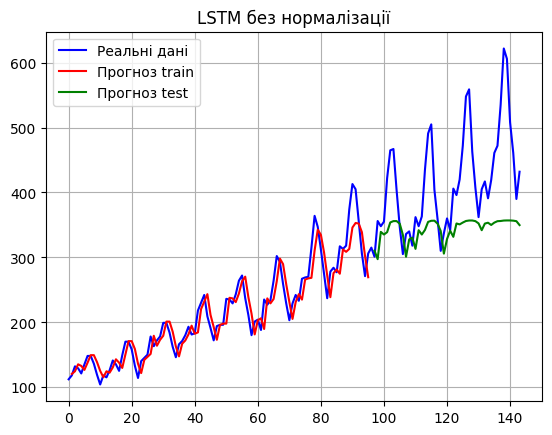

In [24]:
plot_predicts(
    model=model,
    X_train=X_train,
    X_test=X_test,
    title='LSTM без нормалізації'
)

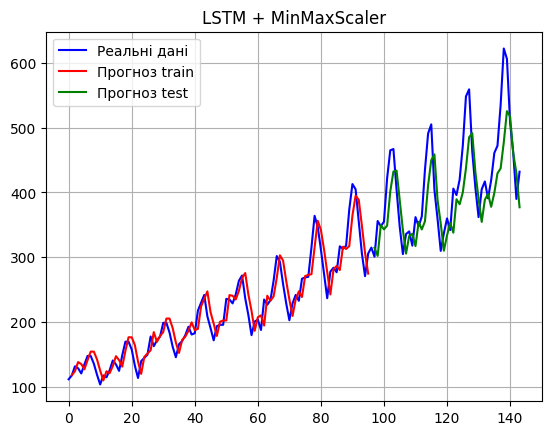

In [25]:
plot_predicts(
    model=model_scaled,
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    title='LSTM + MinMaxScaler',
    is_scaled=True,
    scaler=scaler
)

**Висновки:**

На графіках видно, що обидві моделі навчились відтворювати тренувальну частину часового ряду, але якість прогнозу на тестових даних суттєво відрізняється.

Модель без нормалізації погано узагальнює на тестовій вибірці: прогноз стає надто згладженим і майже не повторює сезонні коливання реального ряду.

Після нормалізації за допомогою MinMaxScaler модель навчається стабільніше і краще прогнозує тестову частину. Прогноз не є ідеальним, оскільки пікові значення все ще занижуються, але зелена лінія значно краще повторює форму реального часового ряду.

**Що відбувається в коді вище.** В цьому коді здійснюється процес прогнозування часових рядів за допомогою LSTM моделі, а також виведення графіку, який показує реальні значення, тренувальні та тестові прогнози. Ось що відбувається на кожному етапі:

1. **`torch.no_grad()`**: Цей контекстний менеджер вимикає обчислення градієнтів, що означає, що під час прогнозування не будуть зберігатися проміжні обчислення для зворотного проходу (backpropagation). Це підвищує ефективність під час прогнозування і зменшує використання пам'яті.

2. **Зсув прогнозів для тренувальних даних:**
   - Створюється масив `train_plot`, який має такий самий розмір, як і часовий ряд (`timeseries`), і заповнюється значеннями NaN (`np.nan`), щоб залишити місце для реальних значень.
   - Модель передбачає виходи для тренувальних даних `X_train`.
   - Використовується лише останнє передбачене значення для кожного входу LSTM (`y_pred[:, -1]`).
   - Прогнози зсуваються, починаючи з індексу `lookback` до кінця тренувальних даних (індекс `train_size`). Цей зсув потрібен, щоб зробити прогноз на основі попередніх даних і відобразити його на правильній частині графіку.

3. **Зсув прогнозів для тестових даних:**
   - Створюється масив `test_plot`, який також заповнюється NaN.
   - Прогнози для тестових даних додаються з індексу `train_size + lookback` до кінця реальних даних, щоб відобразити, де модель починає прогнозувати тестову вибірку.

4. **Побудова графіка:**
   - `plt.plot(timeseries, c='b')`: Виводить реальні значення часового ряду (синя лінія).
   - `plt.plot(train_plot, c='r')`: Виводить тренувальні прогнози (червона лінія).
   - `plt.plot(test_plot, c='g')`: Виводить тестові прогнози (зелена лінія).

**Чому це робиться:**
- Зсув прогнозів для тренувальних і тестових даних дозволяє візуально зрівняти, наскільки добре модель прогнозує як на тренувальній, так і на тестовій вибірках. Зазвичай, червона лінія (тренувальні прогнози) повинна точно відповідати синій лінії (реальні дані), а зелена лінія (тестові прогнози) дає змогу побачити, наскільки модель добре працює на нових даних, яких вона раніше не бачила.

**Завдання 8**. Навчіть модель з hidden_size=100 та порівняйте результати прогнозів з попередніми.

Epoch 0: train RMSE 225.9506, test RMSE 422.3834
Epoch 100: train RMSE 145.0436, test RMSE 336.1585
Epoch 200: train RMSE 96.1999, test RMSE 276.5247
Epoch 300: train RMSE 67.1013, test RMSE 232.0944
Epoch 400: train RMSE 47.4530, test RMSE 195.4534
Epoch 500: train RMSE 36.0632, test RMSE 166.7237
Epoch 600: train RMSE 29.8136, test RMSE 144.6698
Epoch 700: train RMSE 26.7420, test RMSE 127.9186
Epoch 800: train RMSE 25.4956, test RMSE 115.5086
Epoch 900: train RMSE 24.6414, test RMSE 107.1309
Epoch 1000: train RMSE 23.9535, test RMSE 101.2943
Epoch 1100: train RMSE 23.4652, test RMSE 97.6418
Epoch 1200: train RMSE 23.2899, test RMSE 95.3662
Epoch 1300: train RMSE 23.5961, test RMSE 94.9654
Epoch 1400: train RMSE 23.3447, test RMSE 90.3233
Epoch 1500: train RMSE 26.0868, test RMSE 88.8024
Epoch 1600: train RMSE 22.9793, test RMSE 88.8973
Epoch 1700: train RMSE 23.1608, test RMSE 88.3512
Epoch 1800: train RMSE 23.0482, test RMSE 87.9658
Epoch 1900: train RMSE 23.5883, test RMSE 85.0654

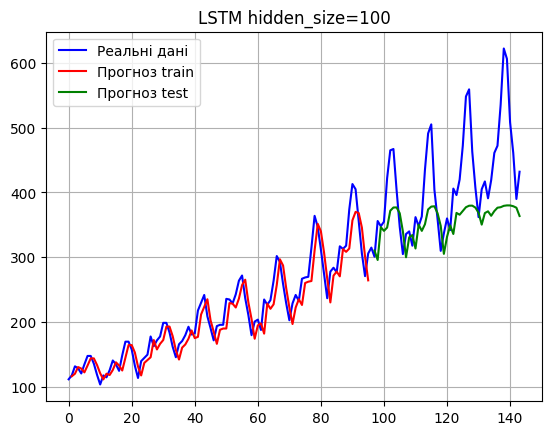

In [26]:
# hidden_size=100: без нормалізації

model_100 = AirModel(hidden_size=100, num_layers=1)

losses_100, metrics_100 = train_air_model(
    model=model_100,
    train_loader=train_dl,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    n_epochs=2000,
    lr=0.001,
)

plot_predicts(
    model=model_100,
    X_train=X_train,
    X_test=X_test,
    title='LSTM hidden_size=100'
)

Epoch 0: train RMSE 0.4442, test RMSE 1.0459
Epoch 100: train RMSE 0.0747, test RMSE 0.1583
Epoch 200: train RMSE 0.0742, test RMSE 0.1563
Epoch 300: train RMSE 0.0738, test RMSE 0.1587
Epoch 400: train RMSE 0.0738, test RMSE 0.1648
Epoch 500: train RMSE 0.0740, test RMSE 0.1619
Epoch 600: train RMSE 0.0737, test RMSE 0.1680
Epoch 700: train RMSE 0.0742, test RMSE 0.1653
Epoch 800: train RMSE 0.0737, test RMSE 0.1668
Epoch 900: train RMSE 0.0738, test RMSE 0.1676
Epoch 1000: train RMSE 0.0737, test RMSE 0.1680
Epoch 1100: train RMSE 0.0738, test RMSE 0.1678
Epoch 1200: train RMSE 0.0738, test RMSE 0.1734
Epoch 1300: train RMSE 0.0756, test RMSE 0.1826
Epoch 1400: train RMSE 0.0736, test RMSE 0.1731
Epoch 1500: train RMSE 0.0737, test RMSE 0.1677
Epoch 1600: train RMSE 0.0738, test RMSE 0.1685
Epoch 1700: train RMSE 0.0737, test RMSE 0.1735
Epoch 1800: train RMSE 0.0737, test RMSE 0.1725
Epoch 1900: train RMSE 0.0742, test RMSE 0.1657
Epoch 1999: train RMSE 0.0744, test RMSE 0.1652


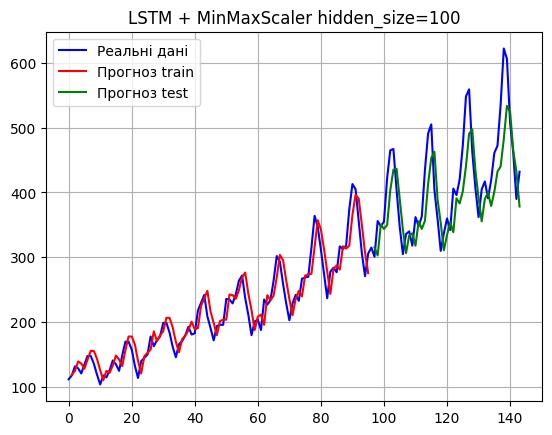

In [27]:
# hidden_size=100: з MinMaxScaler

model_scaled_100 = AirModel(hidden_size=100, num_layers=1)

losses_scaled_100, metrics_scaled_100 = train_air_model(
    model=model_scaled_100,
    train_loader=train_dl_scaled,
    X_train=X_train_scaled,
    y_train=y_train_scaled,
    X_test=X_test_scaled,
    y_test=y_test_scaled,
    n_epochs=2000,
    lr=0.001,
)

plot_predicts(
    model=model_scaled_100,
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    title='LSTM + MinMaxScaler hidden_size=100',
    is_scaled=True,
    scaler=scaler
)

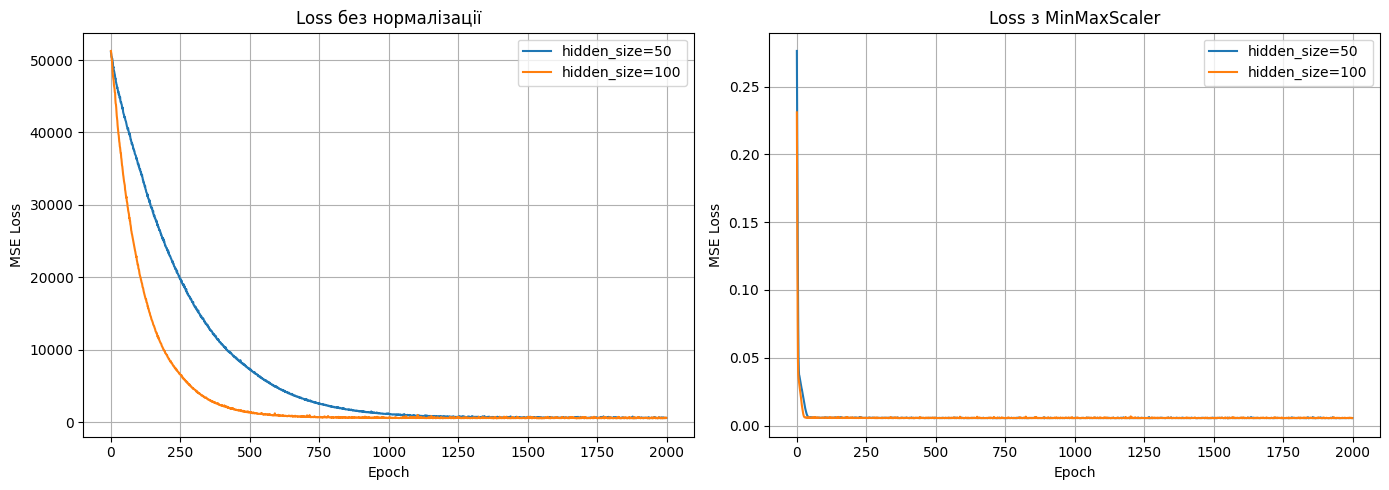

In [28]:
plt.figure(figsize=(14, 5))

# Без нормалізації
plt.subplot(1, 2, 1)
plt.plot(losses, label='hidden_size=50')
plt.plot(losses_100, label='hidden_size=100')
plt.title('Loss без нормалізації')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)

# З нормалізацією
plt.subplot(1, 2, 2)
plt.plot(losses_scaled, label='hidden_size=50')
plt.plot(losses_scaled_100, label='hidden_size=100')
plt.title('Loss з MinMaxScaler')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [29]:
train_rmse_scaled_100, test_rmse_scaled_100 = calculate_real_rmse(
    model=model_scaled_100,
    X_train=X_train_scaled,
    y_train=y_train_scaled,
    X_test=X_test_scaled,
    y_test=y_test_scaled,
    scaler=scaler
)

print(f"Train RMSE у реальній шкалі: {train_rmse_scaled_100:.4f}")
print(f"Test RMSE у реальній шкалі: {test_rmse_scaled_100:.4f}")

Train RMSE у реальній шкалі: 23.0048
Test RMSE у реальній шкалі: 51.0432


In [30]:
# Без нормалізації
_, train_rmse_50, test_rmse_50 = metrics_50[-1]
_, train_rmse_100, test_rmse_100 = metrics_100[-1]

In [31]:
comparison = pd.DataFrame({
    'model': [
        'hidden_size=50',
        'hidden_size=100',
        'MinMaxScaler hidden_size=50',
        'MinMaxScaler hidden_size=100',
    ],
    'train_rmse': [
        train_rmse_50,
        train_rmse_100,
        train_rmse_scaled_50,
        train_rmse_scaled_100,
    ],
    'test_rmse': [
        test_rmse_50,
        test_rmse_100,
        test_rmse_scaled_50,
        test_rmse_scaled_100,
    ],
})

comparison

,model,train_rmse,test_rmse
0,hidden_size=50,23.396204,99.111176
1,hidden_size=100,24.083414,86.402306
2,MinMaxScaler hidden_size=50,22.872032,52.173958
3,MinMaxScaler hidden_size=100,23.004791,51.043182


Після збільшення hidden_size до 100 модель без нормалізації почала навчатися швидше і показала кращий test RMSE порівняно з hidden_size=50. Проте після нормалізації даних збільшення hidden_size дало лише невелике покращення. Отже, для цієї задачі нормалізація має значно більший вплив на якість прогнозу, ніж збільшення розміру прихованого шару.